In [3]:
import pandas as pd

# Columns
cols = ['unit', 'time', 'op1', 'op2', 'op3'] + [f'sensor_{i}' for i in range(1, 22)]

# Load the train
train = pd.read_csv("train_FD001.txt", sep='\s+', header=None)
train.columns = cols

train.head()

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\HP\AppData\Local\Temp\ipykernel_6788\768874503.py:7: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv("train_FD001.txt", sep='\s+', header=None)


,unit,time,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
train.shape

(20631, 26)

Here, we want to know how many engines we have

In [5]:
train['unit'].nunique()

100

the service life of each motor

In [6]:
train.groupby('unit')['time'].max().head()

unit
1    192
2    287
3    179
4    189
5    269
Name: time, dtype: int64

Why are we doing this?

 Because to create the target variable (RUL), we need to:

 know when each engine fails

CRUCIAL step: create the RUL variable

 This is THE heart of the project

Reminder

RUL = Remaining Useful Life

Formula:

RUL = max_cycles - current_cycles

In [8]:
# Calculating the maximum cycle per motor
max_cycle = train.groupby('unit')['time'].max().reset_index()
max_cycle.columns=['unit','max_time']

#Merge with the original dataset
train = train.merge(max_cycle, on ='unit')

#calculating RUL
train['RUL'] = train['max_time'] - train['time']

train.head()

,unit,time,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_time,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [9]:
train[['unit','time','max_time','RUL']].head()

,unit,time,max_time,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


Why is this important?
Now:

Our problem becomes supervised learning

RUL = target variable

Now we’re going to do something really powerful:

 visualise how an engine deteriorates over time

 Objective

To see:

how the sensors change

how the RUL decreases

Step 1: take one engine

In [10]:
engine_1= train[train['unit'] == 1]

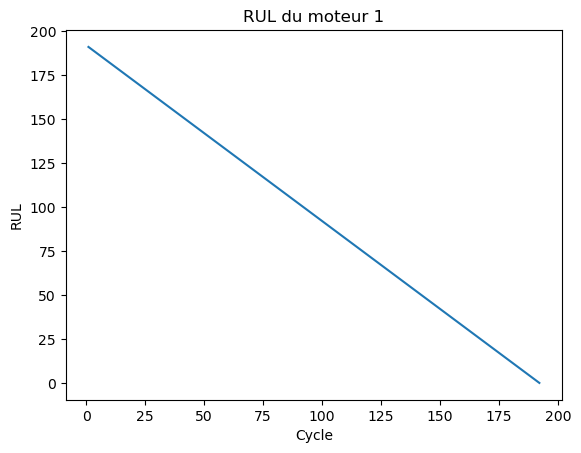

In [11]:
import matplotlib.pyplot as plt

plt.plot(engine_1['time'], engine_1['RUL'])
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title('RUL du moteur 1')
plt.show()

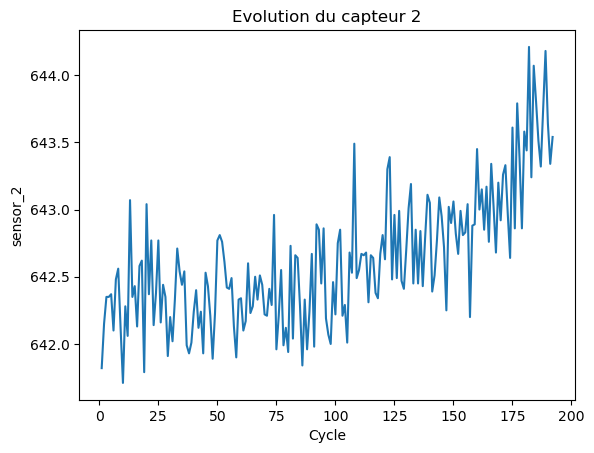

In [12]:
plt.plot(engine_1['time'], engine_1['sensor_2'])
plt.xlabel('Cycle')
plt.ylabel('sensor_2')
plt.title('Evolution du capteur 2')
plt.show()

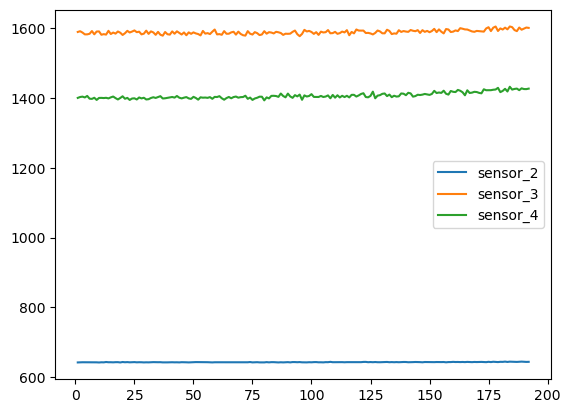

In [13]:
for sensor in ['sensor_2', 'sensor_3', 'sensor_4']:
    plt.plot(engine_1['time'], engine_1[sensor], label=sensor)

plt.legend()
plt.show()

Next step: Feature Selection (highly strategic)

We will identify:

 which sensors are unnecessary

Step 1: identifying constant sensors

In [14]:
train.nunique()

unit          100
time          362
op1           158
op2            13
op3             1
sensor_1        1
sensor_2      310
sensor_3     3012
sensor_4     4051
sensor_5        1
sensor_6        2
sensor_7      513
sensor_8       53
sensor_9     6403
sensor_10       1
sensor_11     159
sensor_12     427
sensor_13      56
sensor_14    6078
sensor_15    1918
sensor_16       1
sensor_17      13
sensor_18       1
sensor_19       1
sensor_20     120
sensor_21    4745
max_time       66
RUL           362
dtype: int64

In [15]:
cols_to_drop = ['op3','sensor_1','sensor_5','sensor_10','sensor_16','sensor_18','sensor_19']
train = train.drop(columns = cols_to_drop)
train.head() 

,unit,time,op1,op2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,max_time,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,...,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,...,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,192,187


In [17]:
train.shape

(20631, 21)

Next step: Standardisation

 Why is this IMPORTANT?

Take a look:

sensor_2 ≈ 600

sensor_14 ≈ 8000

sensor_5 ≈ 14

The scales are different ❌

 Problem:

The model will be biased (favours high values)


 Solution: StandardScaler

We transform the data to get:

mean = 0

standard deviation = 1

In [18]:
from sklearn.preprocessing import StandardScaler

#Features (X)
Features= train.drop(columns = ['unit','time','RUL'])

#Targets (Y)
target = train['RUL']

#Normalisation
scaler = StandardScaler()
x_scaled = scaler.fit_transform(Features)

x_scaled[:5]


array([[-0.31597968, -1.3729532 , -1.72172539, -0.13425518, -0.92593596,
         0.14168333,  1.12114057, -0.51633841, -0.86281332, -0.2664666 ,
         0.33426184, -1.05889024, -0.26907104, -0.6038157 , -0.78170979,
         1.34849274,  1.19442705, -0.49204496],
       [ 0.87272193, -1.03172035, -1.06177971,  0.21152849, -0.64372587,
         0.14168333,  0.43193018, -0.798093  , -0.95881761, -0.19158293,
         1.17489932, -0.363646  , -0.64284474, -0.27585181, -0.78170979,
         1.01652793,  1.23692196, -0.49204496],
       [-1.96187421,  1.01567674, -0.66181262, -0.41316559, -0.52595315,
         0.14168333,  1.00815526, -0.23458381, -0.55713925, -1.0153033 ,
         1.36472069, -0.91984139, -0.55162928, -0.64914404, -2.07309423,
         0.73989059,  0.50342281, -0.49204496],
       [ 0.32409042, -0.00802181, -0.66181262, -1.26131421, -0.78483092,
         0.14168333,  1.22282735,  0.18804808, -0.71382551, -1.53948899,
         1.96130213, -0.22459715, -0.52017567, -1.971

In [19]:
x_scaled.shape

(20631, 18)

Step: Training / Test Split

 We need to split the data:

🟢 Training → training

🔵 Test → evaluation

⚠️ Very important (business logic)

We must not mix the engines!

So:

 we split by unit, not by lines

In [21]:
from sklearn.model_selection import train_test_split

## retrieve unique units
units = train['unit'].unique()

#split engines
train_units, test_units = train_test_split(units, test_size=0.2, random_state=42)

#create datasets
train_data= train[train['unit'].isin(train_units)]
test_data = train[train['unit'].isin(test_units)]

train_data.shape, test_data.shape

((16561, 21), (4070, 21))

Step 2: Separating X and Y

In [22]:
X_train = train_data.drop(columns=['unit', 'time', 'RUL'])
y_train = train_data['RUL']

X_test = test_data.drop(columns=['unit', 'time', 'RUL'])
y_test = test_data['RUL']

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)

rmse, mae

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(37.33756883030624, 30.17744871226054)

In [26]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [27]:
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf, mae_rf

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(36.92102966699008, 26.416331695331696)

# Retrieve the Next Steps (very important)

We’re going to View the predictions:

 To see if the model really understands the problem: unique units

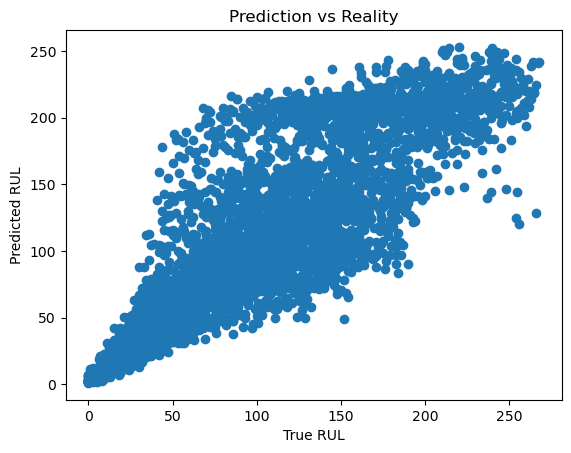

In [28]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Prediction vs Reality")
plt.show()

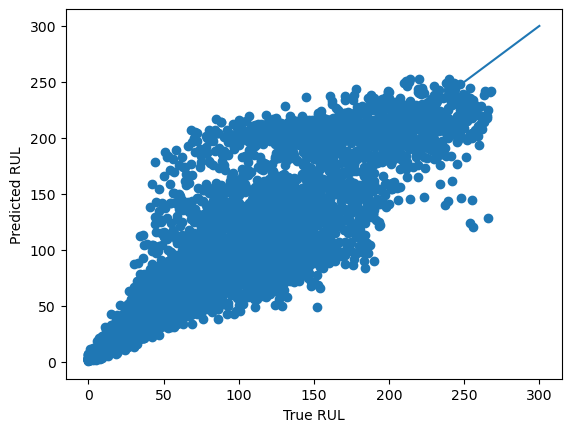

In [29]:
plt.scatter(y_test, y_pred_rf)
plt.plot([0, 300], [0, 300])  # ligne parfaite
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.show()

Next step: intelligent optimisation

We’re going to do something very important in the industry:

 Hyperparameter tuning (Random Forest)

In [30]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf, mae_rf

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(36.683744741039646, 26.254493294925698)